# Lab 3d: Result Summary & Quality Grades

Summarize focal mechanism inversion results and evaluate solution quality.

- Load inversion results from HDF5 files produced by Step 3
- Compute quality grades (A/B/C/D) based on misfit and uncertainty
- Visualize grade distributions and S/P correction factors

**References:**
- Hardebeck, J. L., & Shearer, P. M. (2002). A new method for determining first-motion focal mechanisms. *BSSA*, 92(6), 2264–2276.
- Li, J., Zhu, W., Biondi, E., & Zhan, Z. (2023). Earthquake focal mechanisms with distributed acoustic sensing. *Nature Communications*, 14, 4181.

## Setup

Import libraries and set the project directory.

In [11]:
# Install dasfm (only needed once)
#%pip install -e /home/jovyan/workshop-repo/notebooks/lab3_focal_mechanisms/dasfm

In [ ]:
%matplotlib inline
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("../Inputs/proj_25events")
print(f"Project: {PROJECT_DIR.resolve()}")

## 1. Configuration

Set the inversion modes and result directory to summarize.

In [13]:
from dasfm.utils.step_utils import parse_inversion_types

INVERSION_TYPES = [
    "sta_pol",
    "sta_pol + sta_sp",
    "das_pol",
    "das_pol + das_sp",
    "sta_pol + das_pol",
    "sta_pol + das_sp",
    "sta_pol + das_pol + das_sp",
]

inv_modes = parse_inversion_types(INVERSION_TYPES)

EVENT_CATALOG = PROJECT_DIR / "input/catalog_25events.csv"
RESULT_ROOT = PROJECT_DIR / "result_try1"
BEST_ONLY = True  # True = best candidate only, False = all candidates

catalog = pd.read_csv(EVENT_CATALOG)
event_ids = [str(eid) for eid in catalog["event_id"].values]
n_ev = len(event_ids)

print(f"Events: {n_ev}")
print(f"Result dir: {RESULT_ROOT}")
print(f"Inversion modes: {inv_modes}")
print(f"Best only: {BEST_ONLY}")

Events: 25
Result dir: ../proj_25events/result_try1
Inversion modes: ['STA_pol', 'STA_pol_sp', 'DAS_pol', 'DAS_pol_sp', 'STA_pol_DAS_pol', 'STA_pol_DAS_sp', 'STA_pol_DAS_pol_sp']
Best only: True


## 2. Load Results & Compute Quality Grades

Load all inversion results and assign quality grades based on:
- **Polarity misfit** — fraction of disagreeing polarities
- **Kagan angle uncertainty** — angular spread of acceptable solutions
- **Solution probability** — fraction of grid points that pass the misfit threshold
- **STDR** — station distribution ratio (azimuthal coverage)

In [14]:
from dasfm.utils.result_analysis import (
    PLOT_MODES, JOINTPLOT_MODES, load_grades, load_results,
)
from dasfm.utils.step_utils import MODE_COLORS

grades_df = load_grades(PROJECT_DIR)
active_modes = [m for m in inv_modes if m in PLOT_MODES]

dfs_best, dfs_all = load_results(RESULT_ROOT, event_ids, active_modes, grades_df)
results_use = {m: dfs_best[m].to_dict("records") if BEST_ONLY else dfs_all[m].to_dict("records") for m in PLOT_MODES}
results_all = {m: dfs_all[m].to_dict("records") for m in PLOT_MODES}

for mode in active_modes:
    n_sol = int(dfs_best[mode]["has_solution"].sum()) if "has_solution" in dfs_best[mode].columns else 0
    n_all = len(dfs_all[mode])
    print(f"  {mode:25s}: {n_sol}/{n_ev} events solved, {n_all} total candidates")

  STA_pol                  : 25/25 events solved, 66 total candidates
  STA_pol_sp               : 24/25 events solved, 34 total candidates
  DAS_pol                  : 25/25 events solved, 121 total candidates
  DAS_pol_sp               : 25/25 events solved, 40 total candidates
  STA_pol_DAS_pol          : 25/25 events solved, 45 total candidates
  STA_pol_DAS_sp           : 25/25 events solved, 31 total candidates
  STA_pol_DAS_pol_sp       : 25/25 events solved, 33 total candidates


## Quality Grading Criteria

Each candidate focal mechanism is assigned a quality grade (A/B/C/D) based on 5 metrics. A candidate must satisfy **all** thresholds for a given grade:

| Metric | A | B | C | D |
|--------|---|---|---|---|
| **Polarity misfit** | ≤ 0.15 | ≤ 0.20 | ≤ 0.30 | ≥ 0.30 |
| **Kagan angle uncertainty** | ≤ 25 | ≤ 35 | ≤ 45 | ≥ 45 |
| **STDR**  | ≥ 0.5 | ≥ 0.4 | ≥ 0.3 | ≤ 0.3 |
| **Solution probability** | ≥ 0.8 | ≥ 0.6 | ≥ 0.5 | ≤ 0.5 |
| **S/P misfit rate** (new) | ≤ 0.01 | ≤ 0.02 | ≤ 0.05 | ≥ 0.05 |

### Metric Definitions

- **Polarity misfit** — Fraction of observation points where the predicted P-wave first-motion polarity disagrees with the observed polarity. Lower is better (0 = perfect agreement).

- **Kagan angle uncertainty** — RMS Kagan angle (in degrees) between the cluster average mechanism and all accepted solutions. Measures how well the preferred mechanism represents the full solution space. Lower is better (0 = unique solution).

- **STDR (Station Distribution Ratio)** — Weighted average of sqrt(|P radiation amplitude|) at observation points. Ranges from 0 to 1; higher values indicate observations are further from nodal planes. Applied to all modes. DAS modes typically have high STDR (~0.65, mostly grade A) due to dense channel coverage, so STDR is less discriminating for DAS than for sparse station networks.

- **Solution probability** — Fraction of accepted solutions that belong to this cluster, weighted by MC trial acceptance count. Higher means more solutions consistently point to this mechanism. Ranges from 0 to 1.

- **S/P misfit rate** — Maximum allowed S/P amplitude misfit percentile (0–1), defined as the fraction of candidate mechanisms with misfit less than or equal to the mean misfit of the accepted cluster. Lower values indicate higher S/P fit quality. <span style="color:red"> It is a new quality metrics designed for S-P ratios inversion.</span>

> Candidates that do not meet any A/B/C threshold are assigned grade D.

## 3. Quality Grade Distribution

Bar chart showing how many candidates fall into each quality grade (A/B/C/D) for each inversion mode.

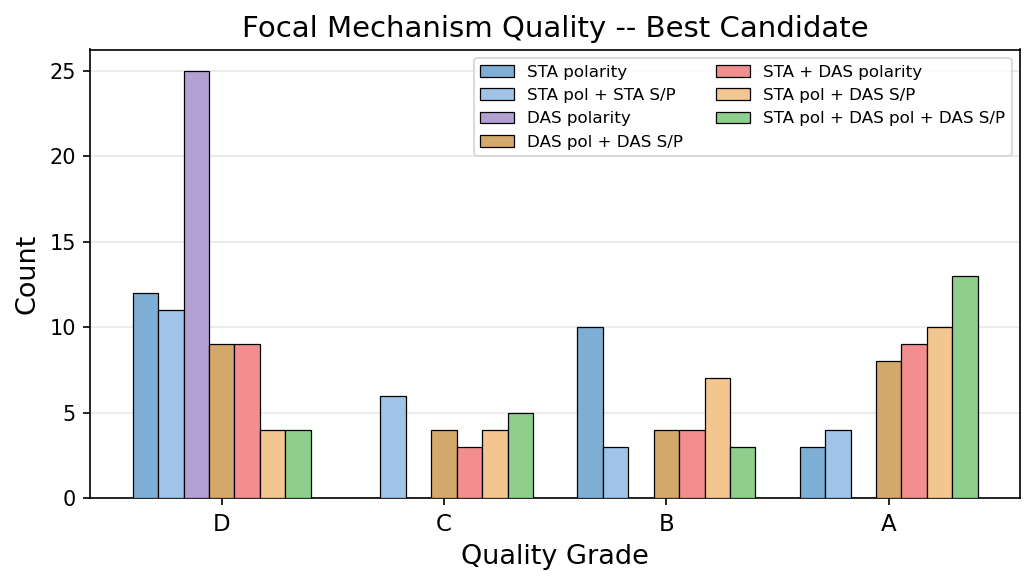

In [15]:
grade_order = ["D", "C", "B", "A"]
stat_label = "Best Candidate" if BEST_ONLY else "All Candidates"

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
n_plot = len(active_modes)
width = 0.8 / max(n_plot, 1)
x = np.arange(len(grade_order))

for i, mode in enumerate(active_modes):
    grades = [r["quality"] for r in results_use[mode]]
    cnt = Counter(grades)
    counts = np.array([cnt.get(g, 0) for g in grade_order])
    offset = (i - (n_plot - 1) / 2) * width
    ax.bar(x + offset, counts, width,
           color=MODE_COLORS[mode], edgecolor="black", linewidth=0.6,
           label=PLOT_MODES[mode]["label"], zorder=3)

ax.grid(axis="y", alpha=0.3, linewidth=0.8, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(grade_order, fontsize=11)
ax.set_xlabel("Quality Grade", fontsize=13)
ax.set_ylabel("Count", fontsize=13)
ax.set_title(f"Focal Mechanism Quality -- {stat_label}", fontsize=14)
ax.legend(fontsize=8, frameon=True, edgecolor="lightgray", ncol=2)
fig.tight_layout()
plt.show()

## 4. Grade Summary Table

In [16]:
print("=" * 80)
print("Quality Grade Summary")
print("=" * 80)
header = f"{'Grade':<14s}"
for mode in active_modes:
    header += f"{PLOT_MODES[mode]['label']:>20s}"
print(header)
print("-" * 80)
for g in ["A", "B", "C", "D"]:
    line = f"{g:<14s}"
    for mode in active_modes:
        cnt = sum(1 for r in results_all[mode] if r["quality"] == g)
        line += f"{cnt:>20d}"
    print(line)
total_line = f"{'Total':<14s}"
for mode in active_modes:
    total_line += f"{len(results_all[mode]):>20d}"
print("-" * 80)
print(total_line)

Quality Grade Summary
Grade                 STA polarity   STA pol + STA S/P        DAS polarity   DAS pol + DAS S/P  STA + DAS polarity   STA pol + DAS S/PSTA pol + DAS pol + DAS S/P
--------------------------------------------------------------------------------
A                                3                   4                   0                   8                   9                  10                  13
B                               10                   3                   0                   4                   4                   7                   3
C                                0                   6                   0                   4                   3                   4                   5
D                               53                  21                 121                  24                  29                  10                  12
--------------------------------------------------------------------------------
Total                           66

## 5. S/P Correction Factor Distribution

For joint modes that use DAS S/P ratios, the inversion applies a mean-alignment correction: `corr_factor = theo_mean - obs_mean`. This corrects for systematic bias between theoretical and observed log₁₀(S/P) values (e.g., due to site effects or coupling variations).

- **Positive** → theoretical S/P systematically higher than observed
- **Near zero** → good agreement between forward model and data

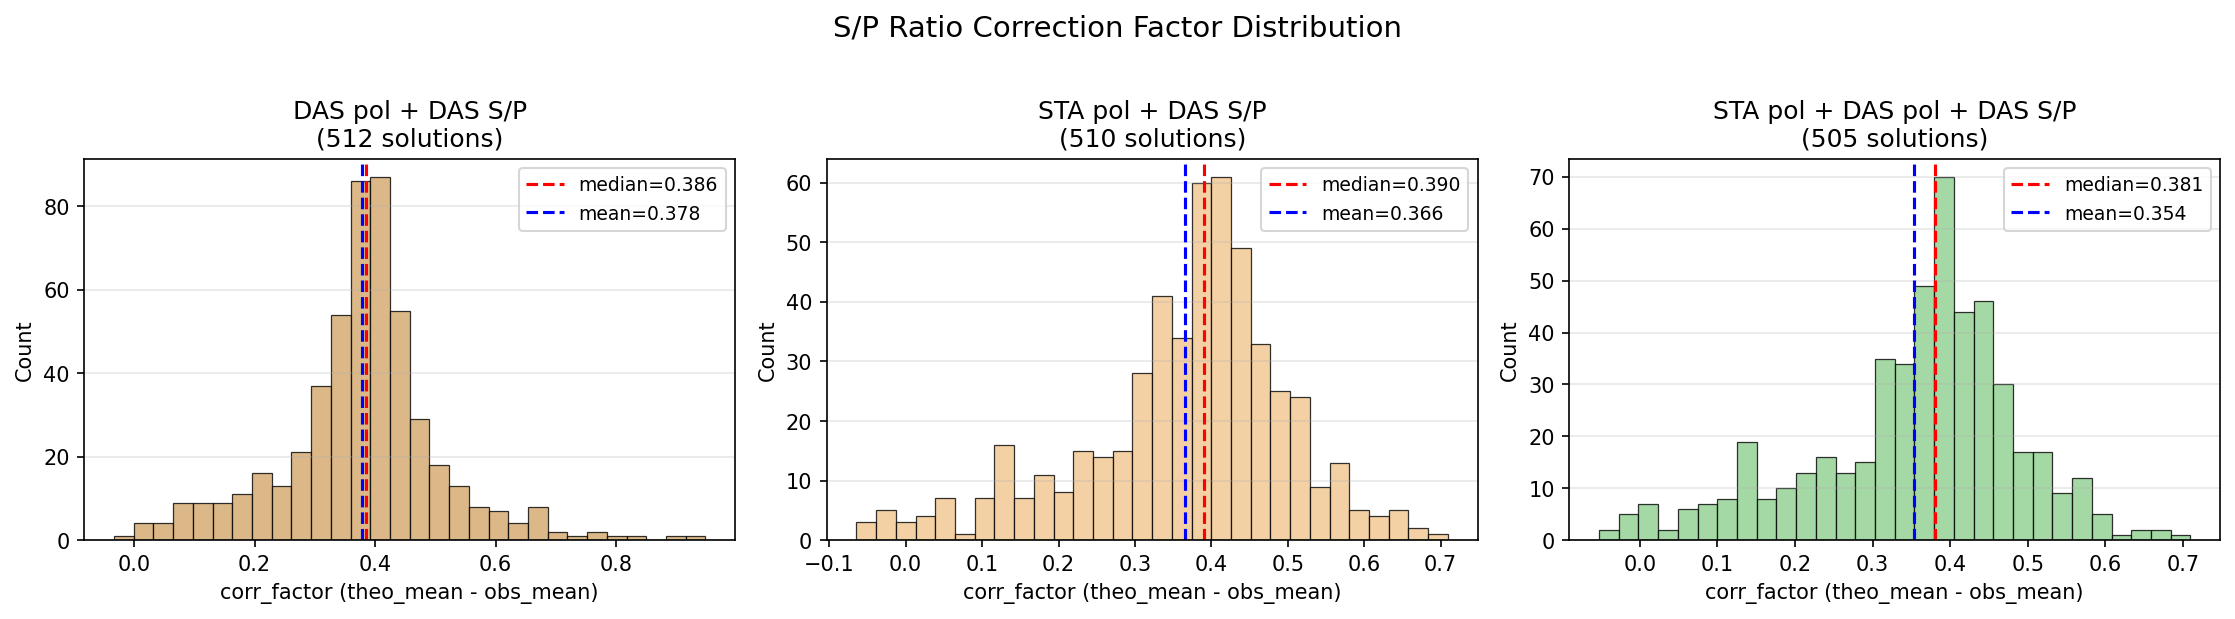

In [17]:
from dasfm.io.result_io import load_inversion_result

# Only DAS S/P joint modes (skip STA_pol_sp — no DAS corr_factor)
cf_modes = [m for m in active_modes if m in JOINTPLOT_MODES and m != "STA_pol_sp"]

if cf_modes:
    cf_data = {}
    for mode in cf_modes:
        cf_all = []
        for eid in event_ids:
            h5_file = RESULT_ROOT / "inv_sol" / eid / f"{mode}.h5"
            if not h5_file.exists(): continue
            data = load_inversion_result(h5_file)
            cf = data.get("corr_factor")
            if cf is not None:
                cf_all.extend(np.asarray(cf).flatten().tolist())
        cf_data[mode] = cf_all

    has_cf = any(len(v) > 0 for v in cf_data.values())
    if has_cf:
        fig, axes = plt.subplots(1, len(cf_modes),
                                 figsize=(5 * len(cf_modes), 4), dpi=150)
        if len(cf_modes) == 1:
            axes = [axes]
        for ax, mode in zip(axes, cf_modes):
            cf_all = cf_data[mode]
            if cf_all:
                cf_arr = np.array(cf_all)
                ax.hist(cf_arr, bins=30, color=MODE_COLORS[mode], edgecolor="black",
                        linewidth=0.6, alpha=0.8)
                ax.axvline(np.median(cf_arr), color="red", ls="--", lw=1.5,
                           label=f"median={np.median(cf_arr):.3f}")
                ax.axvline(np.mean(cf_arr), color="blue", ls="--", lw=1.5,
                           label=f"mean={np.mean(cf_arr):.3f}")
                ax.legend(fontsize=9)
            ax.set_xlabel("corr_factor (theo_mean - obs_mean)")
            ax.set_ylabel("Count")
            ax.set_title(f"{PLOT_MODES[mode]['label']}\n({len(cf_all)} solutions)")
            ax.grid(axis="y", alpha=0.3)
        fig.suptitle("S/P Ratio Correction Factor Distribution", fontsize=14, y=1.02)
        fig.tight_layout()
        plt.show()
    else:
        print("corr_factor plot skipped (no corr_factor in results)")
else:
    print("No DAS S/P joint modes -- corr_factor plot skipped")